# 1. Preprocessing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
os.environ['TF_use_legacy_keras'] = '1'

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
print(tf.__version__)

2.19.0


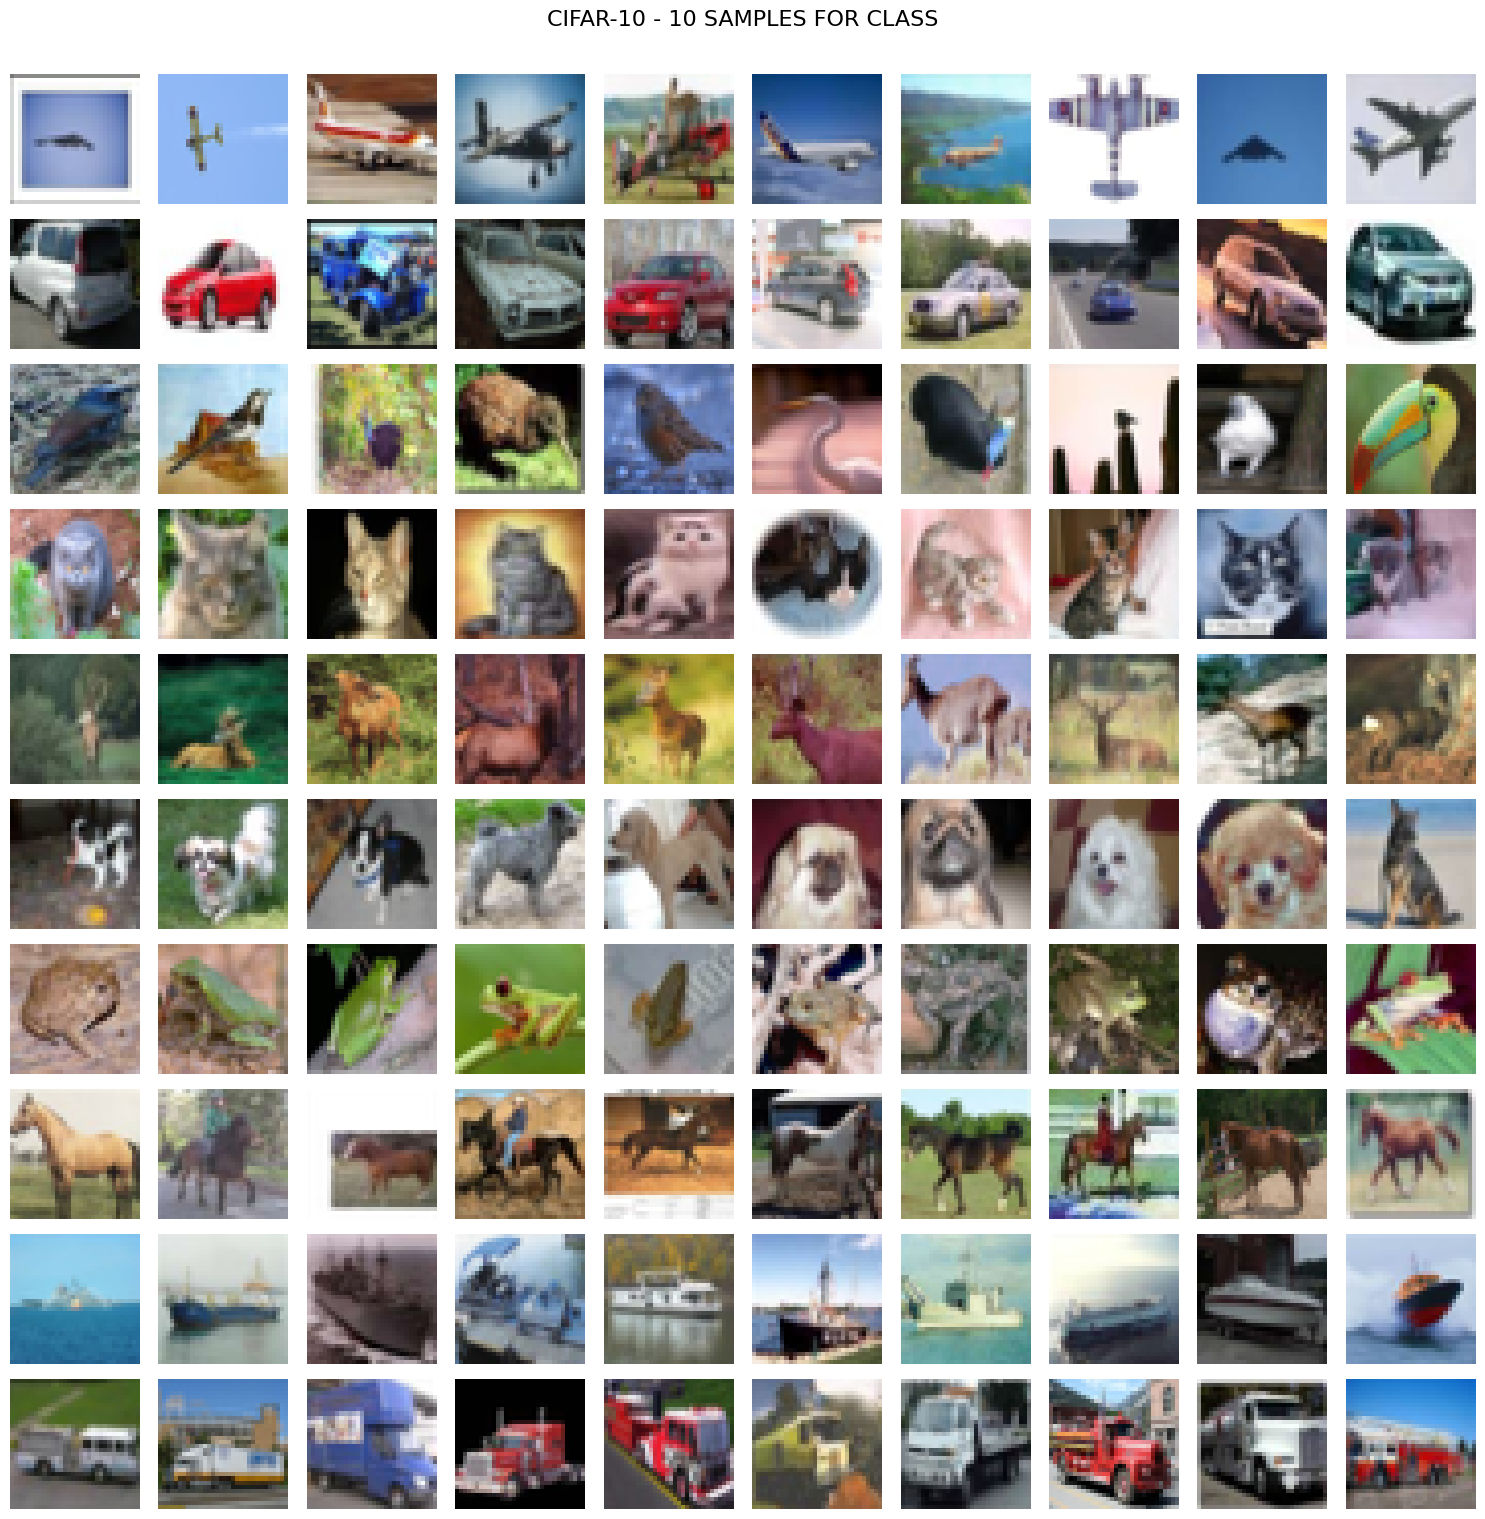

shape labels before: (50000, 1)  ->depois: (50000, 10)
pixel min= 0.0 pixel max= 1.0


In [ ]:
class_names = ['airplane', 'automoblie', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#visualize 10x10
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('CIFAR-10 - 10 SAMPLES FOR CLASS', fontsize=16, y=1.01)

for class_idx in range(10):
  indices = np.where(y_train.flatten() == class_idx)[0]
  samples = np.random.choice(indices, 10, replace=False)
  for col, sample_idx in enumerate(samples):
    ax = axes[class_idx, col]
    ax.imshow(x_train[sample_idx])
    ax.axis('off')
    if col == 0:
      ax.set_ylabel(class_names[class_idx], fontsize=9, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.show()

#normalize
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
print('pixel min=', x_train_norm.min(), 'pixel max=', x_train_norm.max())


# 2. Defining Model (Model Architecture)

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD

#model 3
model3 = Sequential([
    # --- Block 1 ---
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # 32x32 → 16x16

    # --- Block 2 ---
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # 16x16 → 8x8

    # --- Block 3 ---
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # 8x8 → 4x4

    # --- Classifier head ---
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Training

In [ ]:
from sklearn.model_selection import train_test_split

# 90/10 train/validation split
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train_norm, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Training samples:   {x_train_split.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")

Training samples:   45000
Validation samples: 5000


In [ ]:
from tensorflow.keras.optimizers import Adam

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model3.fit(
    x_train_split, y_train_split,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.3218 - loss: 1.8272 - val_accuracy: 0.4580 - val_loss: 1.4606
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4616 - loss: 1.4855 - val_accuracy: 0.5504 - val_loss: 1.2508
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5214 - loss: 1.3376 - val_accuracy: 0.6000 - val_loss: 1.1586
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5552 - loss: 1.2458 - val_accuracy: 0.6260 - val_loss: 1.0721
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5894 - loss: 1.1580 - val_accuracy: 0.6620 - val_loss: 0.9742
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6088 - loss: 1.1009 - val_accuracy: 0.6676 - val_loss: 0.9431
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6267 - loss: 1.0579 - val_accuracy: 0.6944 - val_loss: 0.8729
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6486 - loss: 1.0022 - val_accuracy: 

# 4. Performance

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Validation Loss:     0.6136
Validation Accuracy: 0.7898 (78.98%)

Final Training Loss:       0.5918
Final Training Accuracy:   0.7921 (79.21%)

              precision    recall  f1-score   support

    airplane       0.86      0.81      0.83       500
  automoblie       0.93      0.89      0.91       500
        bird       0.66      0.73      0.69       500
         cat       0.60      0.65      0.62       500
        deer       0.71      0.81      0.76       500
         dog       0.79      0.55      0.64       500
        frog       0.77      0.90      0.83       500
       horse       0.86      0.79      0.82       500
        ship       0.87      0.93      0.90       500
       truck       0.91      0.85      0.88       500

    accuracy                           0.79      5000
   macro avg       0.80      0.79      0.79      5000
weighted avg       0.80      0.79      0.79      5000



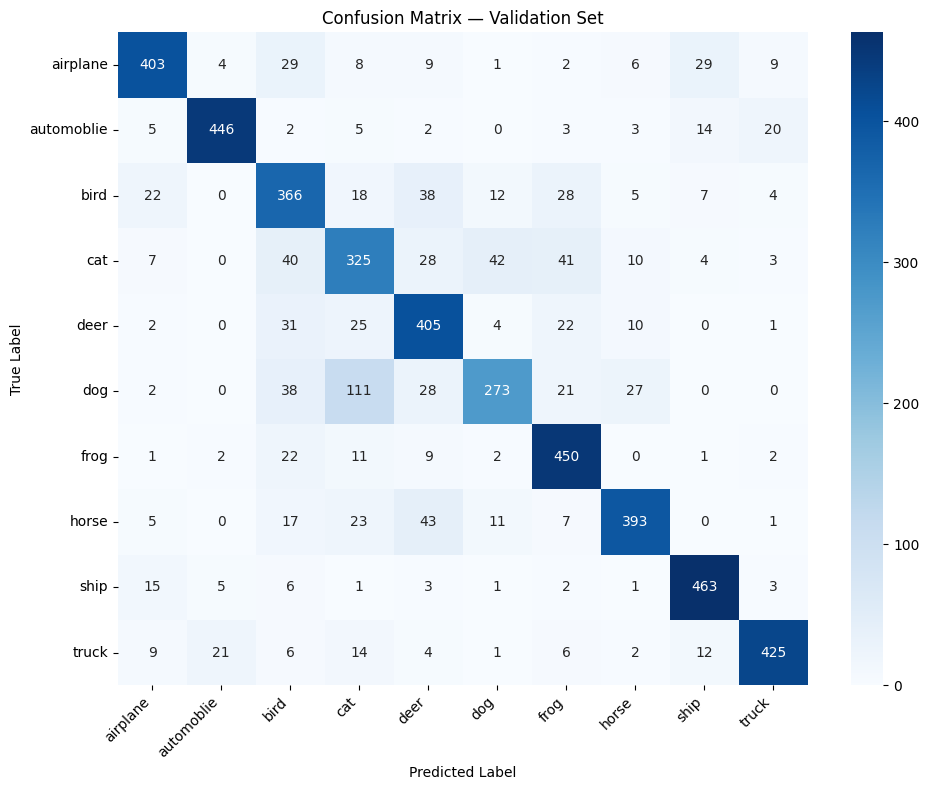

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions on validation set
y_val_pred_probs = model3.predict(x_val)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

# Overall loss & accuracy
val_loss, val_acc = model3.evaluate(x_val, y_val, verbose=0)
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)\n")
train_loss     = history.history['loss']
train_accuracy = history.history['accuracy']

print(f"Final Training Loss:       {train_loss[-1]:.4f}")
print(f"Final Training Accuracy:   {train_accuracy[-1]:.4f} ({train_accuracy[-1]*100:.2f}%)\n")

# Per-class report
print(classification_report(y_val, y_val_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
train_loss     = history.history['loss']
train_accuracy = history.history['accuracy']

test_loss, test_accuracy = model3.evaluate(x_test_norm, y_test, verbose=0)

print(f"Final Training Loss:     {train_loss[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracy[-1]:.4f} ({train_accuracy[-1]*100:.2f}%)")
print(f"Test Loss:               {test_loss:.4f}")
print(f"Test Accuracy:           {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Final Training Loss:     0.5918
Final Training Accuracy: 0.7921 (79.21%)
Test Loss:               0.6361
Test Accuracy:           0.7845 (78.45%)
